In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

ordner = "/content/Daten"
dateien = glob.glob(os.path.join(ordner, "*.csv"))

df_liste = []

for datei in dateien:
    df_temp = pd.read_csv(datei, engine="python", on_bad_lines="skip", sep=";")
    df_temp["quelle_datei"] = os.path.basename(datei)
    df_liste.append(df_temp)

df = pd.concat(df_liste, ignore_index=True)

print(df.head())
print(df.info())

           english_term         spanish_term  migrationsbezug_eng  \
0  Acquired citizenship  Ciudadanía Derivada                    1   
1  Acquired citizenship  Ciudadanía Derivada                    1   
2  Acquired citizenship  Ciudadanía Derivada                    1   
3  Acquired citizenship  Ciudadanía Derivada                    1   
4  Acquired citizenship  Ciudadanía Derivada                    1   

   migrationsbezug_spa  polysemie_eng  polysemie_spa  topic_number  \
0                    1              0              0             1   
1                    1              0              0             1   
2                    1              0              0             1   
3                    1              0              0             1   
4                    1              0              0             1   

                               topic  migrationsbezug_equal  \
0  Rechtlicher Status und Aufenthalt                      1   
1  Rechtlicher Status und Aufenthalt  

In [2]:
clean_df = df[
    ~(
        (
            (df['qs_eng'].notna() & df['qs_migrationsbezug_eng_final'].isna()) |
            (df['qs_spa'].notna() & df['qs_migrationsbezug_spa_final'].isna())
        )
        |
        (df['english_term'] == "Naturalization certificate")
        |
         (df['english_term'] == "Petitioner")
        |
         (df['english_term'] == "Smuggling of migrants")
        |
         (df['english_term'] == "foreigner")

    )
].copy()

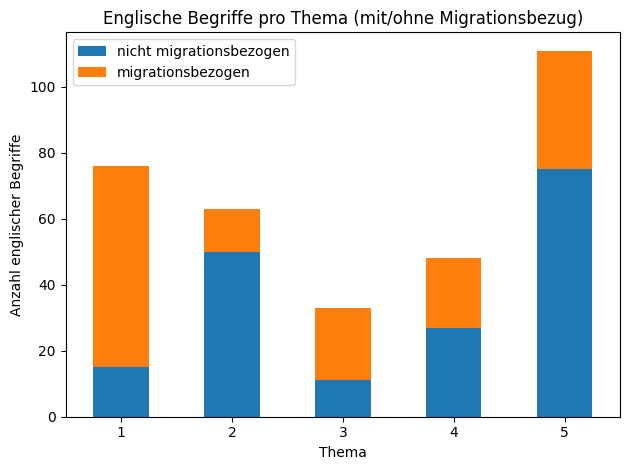

In [3]:
grouped_eng = clean_df.groupby(['topic_number', 'migrationsbezug_eng'])['english_term'].nunique().unstack(fill_value=0)
import matplotlib.pyplot as plt

grouped_eng.plot(kind='bar', stacked=True)

plt.xlabel('Thema')
plt.ylabel('Anzahl englischer Begriffe')
plt.title('Englische Begriffe pro Thema (mit/ohne Migrationsbezug)')
plt.legend(labels=['nicht migrationsbezogen', 'migrationsbezogen'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

               Englisch   Spanisch
topic_number                      
1             61.761506  54.278982
2             27.300059  21.213774
3             64.350856  59.681946
4             42.231398  36.298372
5             21.868881  24.220770


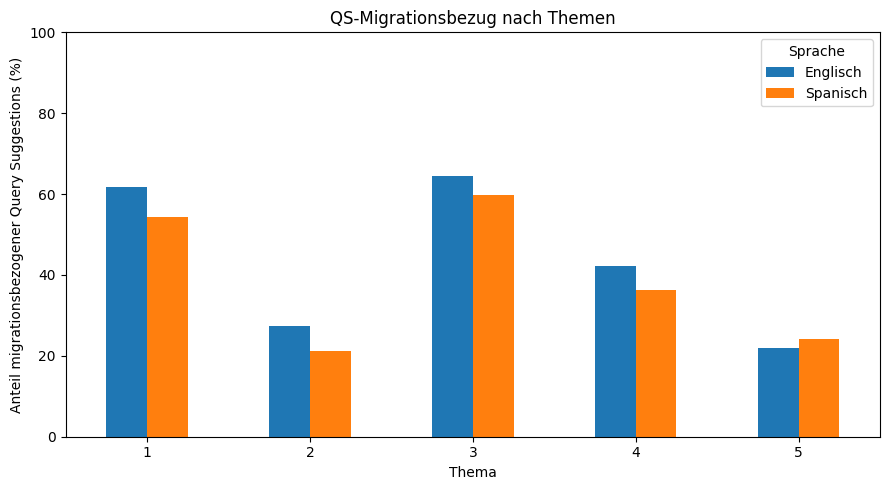

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

# ------------------------------------------------------------
# ENGLISCH:
# Anteil migrationsbezogener englischer QS pro Thema
# ------------------------------------------------------------
subset_eng = df[
    (df['qs_eng'].notna()) &
    (df['qs_migrationsbezug_eng_final'].notna()) &
    (df['topic_number'].notna())
].copy()

eng_by_topic = (
    subset_eng
    .groupby('topic_number')['qs_migrationsbezug_eng_final']
    .mean()
    * 100
)

# ------------------------------------------------------------
# SPANISCH:
# Anteil migrationsbezogener spanischer QS pro Thema
# ------------------------------------------------------------
subset_spa = df[
    (df['qs_spa'].notna()) &
    (df['qs_migrationsbezug_spa_final'].notna()) &
    (df['topic_number'].notna())
].copy()

spa_by_topic = (
    subset_spa
    .groupby('topic_number')['qs_migrationsbezug_spa_final']
    .mean()
    * 100
)

# ------------------------------------------------------------
# Beide in eine Tabelle bringen
# ------------------------------------------------------------
plot_df = pd.DataFrame({
    'Englisch': eng_by_topic,
    'Spanisch': spa_by_topic
}).fillna(0)

print(plot_df)

# ------------------------------------------------------------
# Plot
# -> ergibt 10 Balken: pro Thema je 1 Balken für Englisch und Spanisch
# ------------------------------------------------------------
ax = plot_df.plot(kind='bar', figsize=(9, 5))

plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Themen')

plt.xticks(rotation=0)
plt.legend(title='Sprache')
plt.tight_layout()
plt.show()

Suchterme MIT Migrationsbezug:
               Englisch   Spanisch
topic_number                      
1             75.603552  67.476641
2             85.551995  80.591095
3             92.759023  86.188357
4             90.362688  82.731760
5             61.134601  71.376052

Suchterme OHNE Migrationsbezug:
               Englisch   Spanisch
topic_number                      
1             10.439024   9.998117
2             12.520017   7.703057
3              7.550317  14.407853
4              5.786452   4.262225
5              2.652503   2.061054


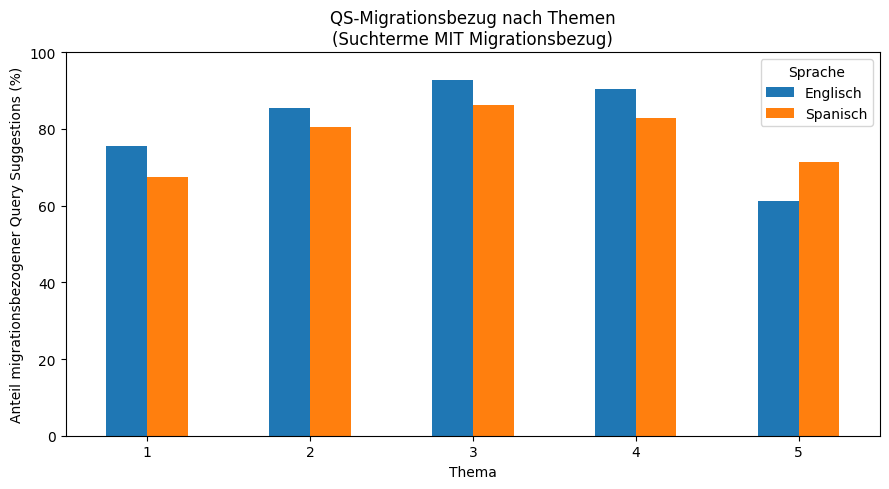

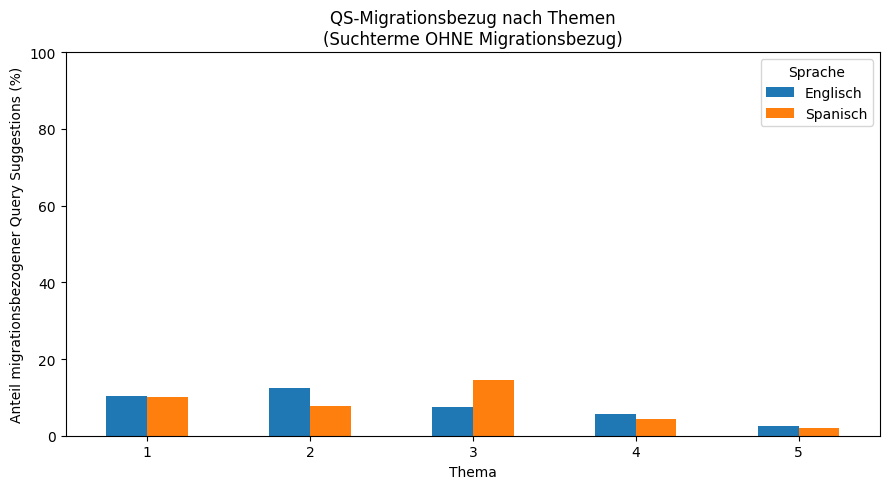

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

# Optional: falls die Spalten nicht sauber numerisch/boolesch sind
# hier sicherstellen, dass 0/1 bzw. True/False sauber verarbeitet werden
for col in [
    'qs_migrationsbezug_eng_final',
    'qs_migrationsbezug_spa_final',
    'migrationsbezug_eng',
    'migrationsbezug_spa'
]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ------------------------------------------------------------
# Funktion:
# Anteil migrationsbezogener QS pro Thema
# getrennt nach Suchtermen mit / ohne Migrationsbezug
# ------------------------------------------------------------
def qs_share_by_topic(df, lang):
    """
    lang = 'eng' oder 'spa'

    Gibt zwei Series zurück:
    - Anteil migrationsbezogener QS pro Thema für Suchterme MIT Migrationsbezug
    - Anteil migrationsbezogener QS pro Thema für Suchterme OHNE Migrationsbezug
    """

    qs_col = f'qs_{lang}'
    qs_mig_col = f'qs_migrationsbezug_{lang}_final'
    term_mig_col = f'migrationsbezug_{lang}'

    subset = df[
        df[qs_col].notna() &
        df[qs_mig_col].notna() &
        df[term_mig_col].notna() &
        df['topic_number'].notna()
    ].copy()

    # Suchterme MIT Migrationsbezug
    with_mig = (
        subset[subset[term_mig_col] == 1]
        .groupby('topic_number')[qs_mig_col]
        .mean() * 100
    )

    # Suchterme OHNE Migrationsbezug
    without_mig = (
        subset[subset[term_mig_col] == 0]
        .groupby('topic_number')[qs_mig_col]
        .mean() * 100
    )

    return with_mig, without_mig

# ------------------------------------------------------------
# Englisch und Spanisch getrennt berechnen
# ------------------------------------------------------------
eng_with_mig, eng_without_mig = qs_share_by_topic(df, 'eng')
spa_with_mig, spa_without_mig = qs_share_by_topic(df, 'spa')

# ------------------------------------------------------------
# In zwei Plot-Tabellen zusammenführen
# ------------------------------------------------------------
plot_df_with_mig = pd.DataFrame({
    'Englisch': eng_with_mig,
    'Spanisch': spa_with_mig
}).fillna(0).sort_index()

plot_df_without_mig = pd.DataFrame({
    'Englisch': eng_without_mig,
    'Spanisch': spa_without_mig
}).fillna(0).sort_index()

print("Suchterme MIT Migrationsbezug:")
print(plot_df_with_mig)

print("\nSuchterme OHNE Migrationsbezug:")
print(plot_df_without_mig)

# ------------------------------------------------------------
# Plot 1: Suchterme MIT Migrationsbezug
# ------------------------------------------------------------
ax = plot_df_with_mig.plot(kind='bar', figsize=(9, 5))
plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Themen\n(Suchterme MIT Migrationsbezug)')
plt.xticks(rotation=0)
plt.legend(title='Sprache')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: Suchterme OHNE Migrationsbezug
# ------------------------------------------------------------
ax = plot_df_without_mig.plot(kind='bar', figsize=(9, 5))
plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Themen\n(Suchterme OHNE Migrationsbezug)')
plt.xticks(rotation=0)
plt.legend(title='Sprache')
plt.tight_layout()
plt.show()

=== Suchterme MIT Migrationsbezug ===
              Englisch – USA  Spanisch – USA  Englisch – Mexiko  \
topic_number                                                      
1                  76.088895       68.717552          74.829274   
2                  85.145215       81.928467          86.193097   
3                  92.005827       87.881863          93.941126   
4                  92.084904       85.688844          87.652201   
5                  60.735190       73.959780          61.755699   

              Spanisch – Mexiko  
topic_number                     
1                     65.484979  
2                     78.484349  
3                     83.551904  
4                     78.178257  
5                     67.355760  

=== Suchterme OHNE Migrationsbezug ===
              Englisch – USA  Spanisch – USA  Englisch – Mexiko  \
topic_number                                                      
1                   9.533333       10.013844          11.854167   
2            

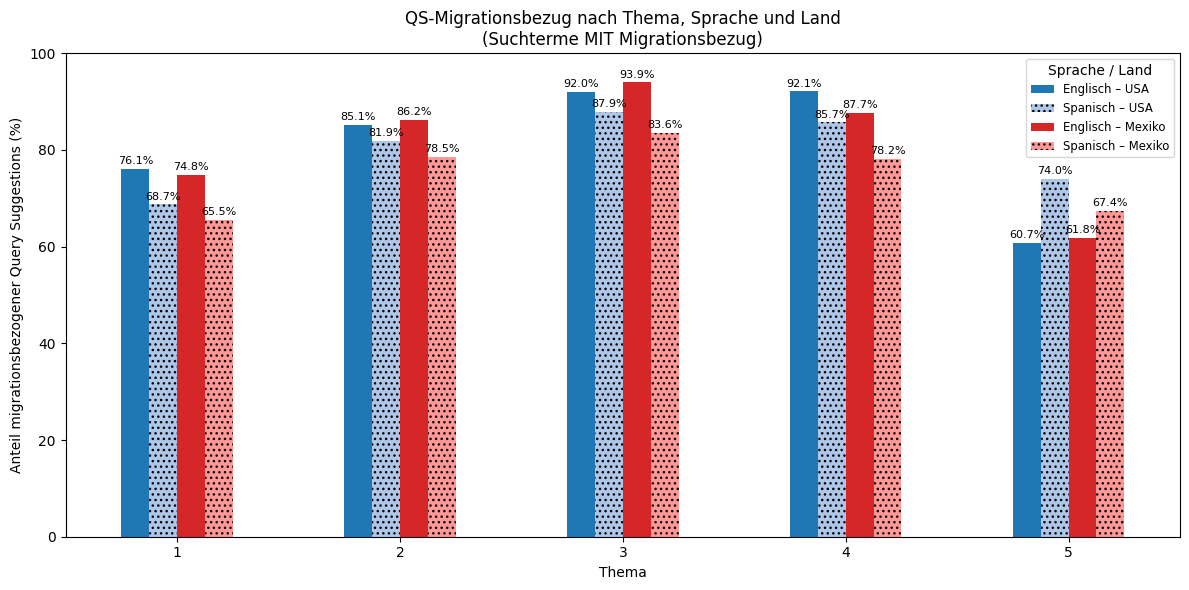

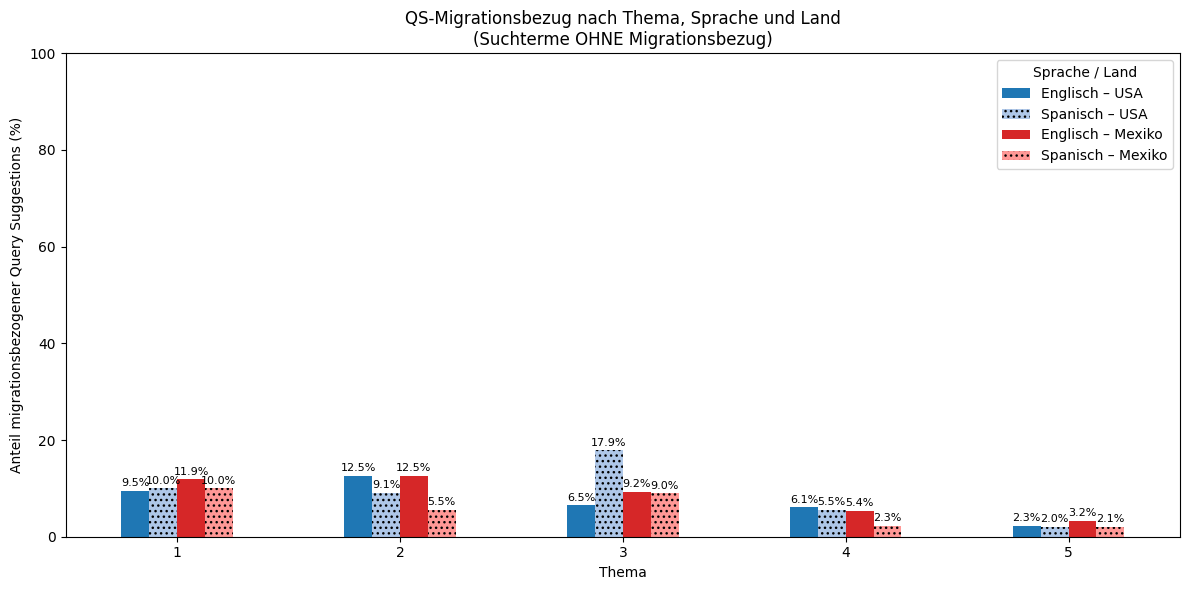

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

# Relevante Länder
laender = ['USA', 'Mexiko']

# Sicherheit: relevante Spalten numerisch machen
for col in [
    'qs_migrationsbezug_eng_final',
    'qs_migrationsbezug_spa_final',
    'migrationsbezug_eng',
    'migrationsbezug_spa',
    'topic_number'
]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ------------------------------------------------------------
# Funktion zum Berechnen der Werte
# ------------------------------------------------------------
def build_plot_df(df, term_has_migration):
    """
    term_has_migration:
        1 = nur Suchterme MIT Migrationsbezug
        0 = nur Suchterme OHNE Migrationsbezug
    """

    result = {}

    for land in laender:
        df_land = df[df['land'] == land]

        # Englisch
        subset_eng = df_land[
            (df_land['qs_eng'].notna()) &
            (df_land['qs_migrationsbezug_eng_final'].notna()) &
            (df_land['migrationsbezug_eng'].notna()) &
            (df_land['migrationsbezug_eng'] == term_has_migration) &
            (df_land['topic_number'].notna())
        ]

        eng_by_topic = (
            subset_eng
            .groupby('topic_number')['qs_migrationsbezug_eng_final']
            .mean() * 100
        )

        # Spanisch
        subset_spa = df_land[
            (df_land['qs_spa'].notna()) &
            (df_land['qs_migrationsbezug_spa_final'].notna()) &
            (df_land['migrationsbezug_spa'].notna()) &
            (df_land['migrationsbezug_spa'] == term_has_migration) &
            (df_land['topic_number'].notna())
        ]

        spa_by_topic = (
            subset_spa
            .groupby('topic_number')['qs_migrationsbezug_spa_final']
            .mean() * 100
        )

        result[f'Englisch – {land}'] = eng_by_topic
        result[f'Spanisch – {land}'] = spa_by_topic

    plot_df = pd.DataFrame(result).fillna(0).sort_index()
    return plot_df

# ------------------------------------------------------------
# Daten für beide Gruppen
# ------------------------------------------------------------
plot_df_with_mig = build_plot_df(df, term_has_migration=1)
plot_df_without_mig = build_plot_df(df, term_has_migration=0)

print("=== Suchterme MIT Migrationsbezug ===")
print(plot_df_with_mig)

print("\n=== Suchterme OHNE Migrationsbezug ===")
print(plot_df_without_mig)

# ------------------------------------------------------------
# Farben und Hatches
# ------------------------------------------------------------
colors = [
    '#1f77b4',  # Englisch – USA
    '#aec7e8',  # Spanisch – USA
    '#d62728',  # Englisch – Mexiko
    '#ff9896'   # Spanisch – Mexiko
]

hatches = ['', '...', '', '...']  # Spanisch gepunktet

# ------------------------------------------------------------
# Plot 1: Suchterme MIT Migrationsbezug
# ------------------------------------------------------------
ax = plot_df_with_mig.plot(
    kind='bar',
    figsize=(12, 6),
    color=colors
)

for bars, hatch in zip(ax.containers, hatches):
    for bar in bars:
        bar.set_hatch(hatch)

plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Thema, Sprache und Land\n(Suchterme MIT Migrationsbezug)')
plt.xticks(rotation=0)

ax.legend(title='Sprache / Land',fontsize='small')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: Suchterme OHNE Migrationsbezug
# ------------------------------------------------------------
ax = plot_df_without_mig.plot(
    kind='bar',
    figsize=(12, 6),
    color=colors
)

for bars, hatch in zip(ax.containers, hatches):
    for bar in bars:
        bar.set_hatch(hatch)

plt.ylabel('Anteil migrationsbezogener Query Suggestions (%)')
plt.xlabel('Thema')
plt.ylim(0, 100)
plt.title('QS-Migrationsbezug nach Thema, Sprache und Land\n(Suchterme OHNE Migrationsbezug)')
plt.xticks(rotation=0)
ax.legend(title='Sprache / Land')


for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

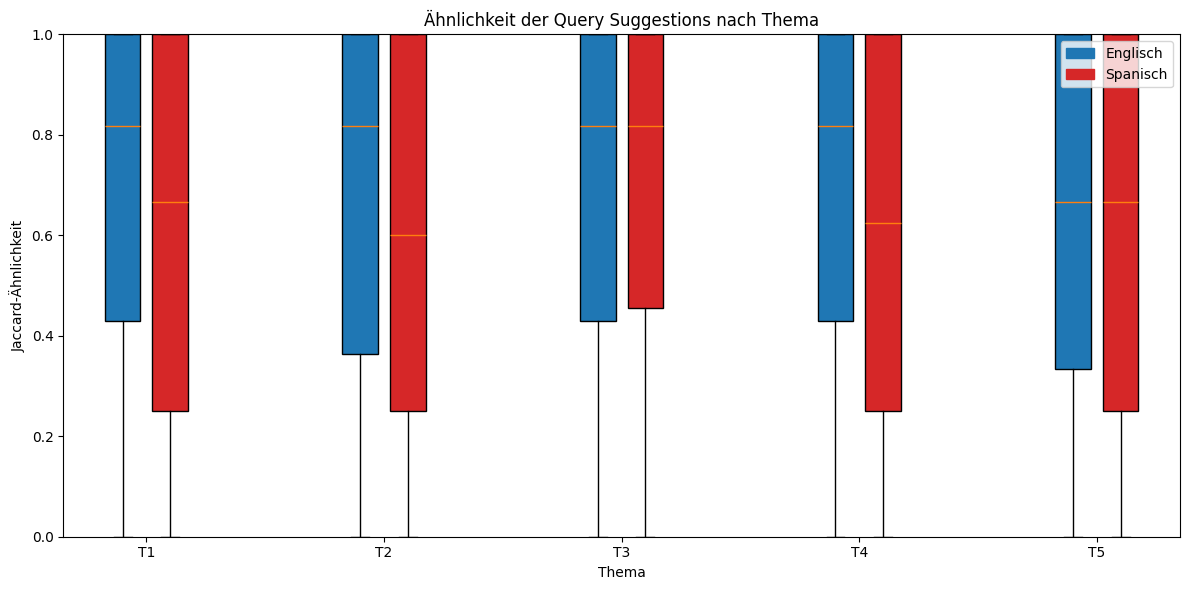

In [10]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Datengrundlage
# ------------------------------------------------------------
df = clean_df.copy()

df_en = df[
    (df['qs_eng'].notna()) &
    (df['english_term'].notna()) &
    (df['topic_number'].notna())
].copy()

df_es = df[
    (df['qs_spa'].notna()) &
    (df['spanish_term'].notna()) &
    (df['topic_number'].notna())
].copy()

# ------------------------------------------------------------
# Standort-ID
# ------------------------------------------------------------
def add_location_id(df):
    df['location_id'] = (
        df['land'].astype(str) + " | " +
        df['bundesstaat'].astype(str) + " | " +
        df['stadt'].astype(str)
    )
    return df

df_en = add_location_id(df_en)
df_es = add_location_id(df_es)

# ------------------------------------------------------------
# Jaccard
# ------------------------------------------------------------
def jaccard_similarity(set_a, set_b):
    if not set_a and not set_b:
        return np.nan
    union = set_a | set_b
    if len(union) == 0:
        return np.nan
    return len(set_a & set_b) / len(union)

# ------------------------------------------------------------
# Funktion: Similarity pro Thema (mit Standort!)
# ------------------------------------------------------------
def compute_similarity_per_topic(df, term_col, qs_col):

    # Sets pro Term + Standort
    term_loc_sets = (
        df.groupby(['topic_number', term_col, 'location_id'])[qs_col]
        .apply(lambda x: set(x.dropna().astype(str).str.strip()))
        .reset_index(name='qs_set')
    )

    topic_results = {}

    for topic, group in term_loc_sets.groupby('topic_number'):

        sims = []

        # pro Term vergleichen (Standorte untereinander)
        for term, sub in group.groupby(term_col):
            loc_sets = list(sub['qs_set'])

            if len(loc_sets) < 2:
                continue

            for set1, set2 in combinations(loc_sets, 2):
                sims.append(jaccard_similarity(set1, set2))

        if sims:
            topic_results[topic] = sims

    return topic_results

# ------------------------------------------------------------
# Berechnung
# ------------------------------------------------------------
eng_dict = compute_similarity_per_topic(df_en, 'english_term', 'qs_eng')
spa_dict = compute_similarity_per_topic(df_es, 'spanish_term', 'qs_spa')

topics = sorted(set(eng_dict.keys()) | set(spa_dict.keys()))

# ------------------------------------------------------------
# Boxplot vorbereiten
# ------------------------------------------------------------
plot_data = []
positions = []
labels = []

pos = 1

for topic in topics:

    # Englisch
    plot_data.append(pd.Series(eng_dict.get(topic, [])).dropna())
    positions.append(pos)

    # Spanisch
    plot_data.append(pd.Series(spa_dict.get(topic, [])).dropna())
    positions.append(pos + 0.4)

    labels.append(f'T{topic}')
    pos += 2

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

bp = plt.boxplot(plot_data, positions=positions, widths=0.3, patch_artist=True)

# Farben
colors = ['#1f77b4', '#d62728'] * len(topics)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# X-Ticks
tick_positions = [i + 0.2 for i in range(1, len(topics)*2, 2)]
plt.xticks(tick_positions, labels)

plt.ylabel('Jaccard-Ähnlichkeit')
plt.xlabel('Thema')
plt.title('Ähnlichkeit der Query Suggestions nach Thema')

# Legende
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color='#1f77b4', label='Englisch'),
    mpatches.Patch(color='#d62728', label='Spanisch')
]
plt.legend(handles=legend_patches)

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [12]:
summary_rows = []

for topic in topics:
    eng_vals = pd.Series(eng_dict.get(topic, [])).dropna()
    spa_vals = pd.Series(spa_dict.get(topic, [])).dropna()

    summary_rows.append({
        'Thema': topic,
        'Englisch Mean': eng_vals.mean(),
        'Englisch Median': eng_vals.median(),
        'Spanisch Mean': spa_vals.mean(),
        'Spanisch Median': spa_vals.median()
    })

summary_df = pd.DataFrame(summary_rows)

print(summary_df.round(3))

   Thema  Englisch Mean  Englisch Median  Spanisch Mean  Spanisch Median
0      1          0.713            0.818          0.624            0.667
1      2          0.706            0.818          0.599            0.600
2      3          0.688            0.818          0.734            0.818
3      4          0.689            0.818          0.599            0.625
4      5          0.618            0.667          0.624            0.667
